
# Donnan equilibrium vs. Nernst vs. GHK

Living-systems / semiconductor-systems analogy — Part A.

**Goal of this notebook:** compare three models of how a membrane potential arises, and see where
they agree and where they diverge:

1. **Nernst equation** — equilibrium potential for a *single* permeant ion.
2. **Goldman-Hodgkin-Katz (GHK) equation** — steady-state potential when *several* ions permeate
   with different conductances/permeabilities (this is the model that matches a real, pumped
   neuron at rest).
3. **Gibbs–Donnan equilibrium** — what happens with *no pump*, when an impermeant charged
   species (e.g. intracellular protein) is trapped on one side of the membrane and the permeant
   ions redistribute passively to satisfy electroneutrality *and* their own Nernst equilibrium
   simultaneously.

Then in the second half we go dynamic: instead of jumping straight to equilibrium, we integrate
ion fluxes over time and **animate** the system relaxing toward Donnan equilibrium (no pump) vs.
holding a GHK-like steady state (with a pump term added) — a direct, visual version of "passive
network vs. active device," which is the semiconductor-analogy hook for this course section.



## Glossary of symbols

| Symbol | Meaning | Value/units used here |
|---|---|---|
| $R$ | Universal gas constant | 8.314 J/(mol·K) |
| $T$ | Absolute temperature | 310 K (~37°C, body temp) |
| $F$ | Faraday's constant (charge per mole of monovalent ions) | 96485 C/mol |
| $z$ | Valence (charge number) of an ion | +1 for K+/Na+, -1 for Cl-/A- |
| $[X]_o$, $[X]_i$ | Concentration of ion $X$ outside / inside the cell | mM |
| $E_X$ | Nernst equilibrium potential for ion $X$ (the $V_m$ at which that ion alone has zero net flux) | mV |
| $V_m$ | Membrane potential (inside relative to outside) | mV |
| $P_K, P_{Na}, P_{Cl}$ | Relative membrane permeability for that ion (GHK weight; later reused as channel-gate width / conductance) | dimensionless (relative) |
| $A^-$ | The impermeant intracellular anion (e.g. protein) trapped inside — can't cross the membrane | valence -1 in our examples |
| $r$ | Donnan ratio, $[K^+]_i/[K^+]_o = [Cl^-]_o/[Cl^-]_i$ | dimensionless |
| $I_X$ | Ionic current for species $X$, $I_X = P_X(V_m - E_X)$ (outward-positive convention) | arbitrary units in the toy ODE |
| $q$ | Charge of a simulated ion particle (pymunk section) | +1 or -1 (unit charges) |

$\frac{RT}{F} \approx 26.7$ mV at 310 K — this combination recurs throughout the Nernst/GHK
formulas as the prefactor in front of every $\ln(\cdot)$ term.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Physical constants
R = 8.314          # J / (mol K)
F = 96485           # C / mol
T = 310.0            # K, ~37 C (body temp)

def nernst_mV(z, c_out, c_in, T=T):
    """Nernst equilibrium potential (mV) for ion of valence z, outside/inside conc in same units."""
    return 1000 * (R * T) / (z * F) * np.log(c_out / c_in)



## 1. Nernst potentials for the classic ions

Typical mammalian neuron concentrations (mM), roughly:

| Ion | Outside | Inside |
|---|---|---|
| K+  | 5   | 140 |
| Na+ | 145 | 12  |
| Cl- | 110 | 4   |


In [2]:
conc = {
    "K":  dict(z=+1, out=5.0,   inn=140.0),
    "Na": dict(z=+1, out=145.0, inn=12.0),
    "Cl": dict(z=-1, out=110.0, inn=4.0),
}

for ion, c in conc.items():
    e = nernst_mV(c["z"], c["out"], c["inn"])
    print(f"E_{ion:<3s} = {e:7.2f} mV")


E_K   =  -89.01 mV
E_Na  =   66.56 mV
E_Cl  =  -88.53 mV



## 2. GHK equation — steady state with mixed permeabilities

$$
V_m = \frac{RT}{F} \ln \left( \frac{P_K [K^+]_o + P_{Na}[Na^+]_o + P_{Cl}[Cl^-]_i}
                                    {P_K [K^+]_i + P_{Na}[Na^+]_i + P_{Cl}[Cl^-]_o} \right)
$$

Note Cl- (a negative ion) has inside/outside swapped relative to the cations — that's what
keeps the equation consistent with each ion's own Nernst potential when its permeability
dominates.


In [3]:
def ghk_mV(pK, pNa, pCl, conc=conc, T=T):
    num = pK*conc["K"]["out"] + pNa*conc["Na"]["out"] + pCl*conc["Cl"]["inn"]
    den = pK*conc["K"]["inn"] + pNa*conc["Na"]["inn"] + pCl*conc["Cl"]["out"]
    return 1000 * (R*T/F) * np.log(num/den)

# Typical resting permeability ratios (K highly dominant at rest)
print("Resting GHK Vm  :", round(ghk_mV(pK=1.0, pNa=0.04, pCl=0.45), 2), "mV")
print("All-K limit     :", round(ghk_mV(pK=1.0, pNa=0.0,  pCl=0.0), 2), "mV  (should match E_K)")
print("All-Na limit    :", round(ghk_mV(pK=0.0, pNa=1.0,  pCl=0.0), 2), "mV  (should match E_Na)")


Resting GHK Vm  : -72.48 mV
All-K limit     : -89.01 mV  (should match E_K)
All-Na limit    : 66.56 mV  (should match E_Na)


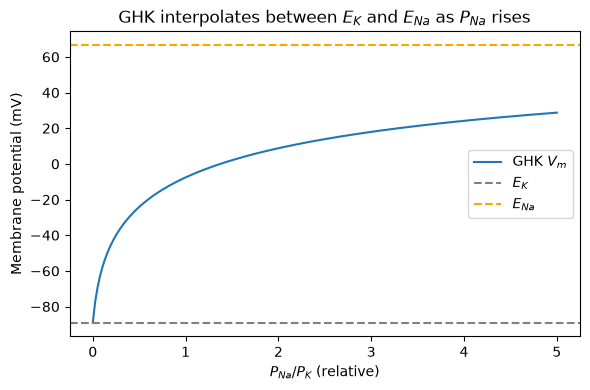

In [4]:
# Sweep Na permeability (e.g. during an action potential upstroke, P_Na rises sharply)
pNa_values = np.linspace(0.0, 5.0, 200)
vm_values = [ghk_mV(pK=1.0, pNa=pNa, pCl=0.45) for pNa in pNa_values]

plt.figure(figsize=(6,4))
plt.plot(pNa_values, vm_values, label="GHK $V_m$")
plt.axhline(nernst_mV(+1, conc["K"]["out"], conc["K"]["inn"]), ls="--", color="gray", label="$E_K$")
plt.axhline(nernst_mV(+1, conc["Na"]["out"], conc["Na"]["inn"]), ls="--", color="orange", label="$E_{Na}$")
plt.xlabel("$P_{Na} / P_K$ (relative)")
plt.ylabel("Membrane potential (mV)")
plt.title("GHK interpolates between $E_K$ and $E_{Na}$ as $P_{Na}$ rises")
plt.legend()
plt.tight_layout()
plt.show()



## 3. Gibbs–Donnan equilibrium — the no-pump passive limit

Setup: two compartments (in/out), separated by a membrane permeable to K+ and Cl- but *not* to
an intracellular anion **A-** (protein), with valence $z_A$ and fixed intracellular amount.
No pump — everything just diffuses until equilibrium.

At Donnan equilibrium, K+ and Cl- must **each individually** sit at their own Nernst potential,
and both equal the *same* membrane potential (only one membrane, one $V_m$):

$$
\frac{RT}{F}\ln\frac{[K^+]_o}{[K^+]_i} = \frac{RT}{F}\ln\frac{[Cl^-]_i}{[Cl^-]_o} = V_m^{Donnan}
$$

which forces the **Donnan ratio**:

$$
r = \frac{[K^+]_i}{[K^+]_o} = \frac{[Cl^-]_o}{[Cl^-]_i}
$$

Combined with charge conservation (total K+ and Cl- moles are fixed by however much started on
each side) and electroneutrality (inside: $[K^+]_i = [Cl^-]_i + z_A[A^-]$, since A- is trapped
inside), we can solve for $r$ numerically given a starting condition.


In [5]:
def solve_donnan(K_total, Cl_total, A_inside, V_in=1.0, V_out=1.0, z_A=1):
    """
    Solve 2-compartment Donnan equilibrium for K+ / Cl- with a trapped impermeant anion A- inside.

    K_total, Cl_total : total moles of K+ / Cl- across both compartments (conserved)
    A_inside          : moles of impermeant anion, confined to inside compartment
    V_in, V_out       : compartment volumes (affects concentrations, here just use 1:1 by default)
    z_A               : valence magnitude of the impermeant anion (assumed negative charge)

    Returns dict of equilibrium concentrations, Donnan ratio r, and V_m (mV).
    Uses the Donnan ratio r = [K]_in/[K]_out = [Cl]_out/[Cl]_in, plus conservation +
    electroneutrality, reduced to a single equation in r solved by bisection.
    """
    def residual(r):
        K_out = K_total / (r*V_in + V_out)
        K_in  = r * K_out
        Cl_in  = Cl_total / (V_in + r*V_out)
        Cl_out = r * Cl_in
        A_in = A_inside / V_in
        return (K_in) - (Cl_in + z_A*A_in)

    # residual(r) = K_in - (Cl_in + z_A*A_in) is monotonically increasing in r
    # (as r grows, K_in grows toward K_total and Cl_in shrinks toward 0)
    lo, hi = 1e-6, 1e6
    f_lo, f_hi = residual(lo), residual(hi)
    assert f_lo < 0 and f_hi > 0, "bracket doesn't contain a root, adjust inputs"
    for _ in range(200):
        mid = 0.5*(lo+hi)
        f_mid = residual(mid)
        if f_mid < 0:
            lo = mid
        else:
            hi = mid
    r = 0.5*(lo+hi)

    K_out = K_total / (r*V_in + V_out); K_in = r*K_out
    Cl_in = Cl_total / (V_in + r*V_out); Cl_out = r*Cl_in
    Vm = nernst_mV(+1, K_out, K_in)  # = -nernst_mV(-1, Cl_out, Cl_in), same value

    return dict(r=r, K_in=K_in, K_out=K_out, Cl_in=Cl_in, Cl_out=Cl_out, Vm_mV=Vm)


In [6]:
result = solve_donnan(K_total=145.0, Cl_total=115.0, A_inside=100.0, z_A=1)
for k, v in result.items():
    print(f"{k:8s} = {v:.4f}")

print()
print("Check electroneutrality inside : [K]_in - [Cl]_in =", round(result["K_in"] - result["Cl_in"], 6),
      " should equal [A]_in = 100.0")
print("Check Donnan product           : [K]_in*[Cl]_in vs [K]_out*[Cl]_out =",
      round(result["K_in"]*result["Cl_in"], 3), "vs", round(result["K_out"]*result["Cl_out"], 3))


r        = 4.7778
K_in     = 119.9038
K_out    = 25.0962
Cl_in    = 19.9038
Cl_out   = 95.0962
Vm_mV    = -41.7774

Check electroneutrality inside : [K]_in - [Cl]_in = 100.0  should equal [A]_in = 100.0
Check Donnan product           : [K]_in*[Cl]_in vs [K]_out*[Cl]_out = 2386.548 vs 2386.548



## 4. Osmotic imbalance — why Donnan alone can't be the whole story

A real neuron does NOT sit at Donnan equilibrium; it's held at a GHK-style steady state by the
Na+/K+-ATPase. One big reason: Donnan equilibrium creates more total osmotically active
particles on the side with the trapped impermeant anion (protein), which pulls in water — the
cell would swell and eventually lyse without active pumping.

Let's quantify that with the numbers above.


In [7]:
inside_osm  = result["K_in"] + result["Cl_in"] + 100.0   # + impermeant A-
outside_osm = result["K_out"] + result["Cl_out"]

print(f"Inside total osmolytes : {inside_osm:.2f} (mM-equivalent)")
print(f"Outside total osmolytes: {outside_osm:.2f} (mM-equivalent)")
print(f"Imbalance (in - out)   : {inside_osm - outside_osm:+.2f}  -> net water influx driving swelling")


Inside total osmolytes : 239.81 (mM-equivalent)
Outside total osmolytes: 120.19 (mM-equivalent)
Imbalance (in - out)   : +119.62  -> net water influx driving swelling



## 5. Comparing all three side by side

- **Nernst**: single-ion equilibrium potential — the "if only this ion mattered" baseline.
- **Donnan**: multi-ion *passive* equilibrium in the presence of a trapped charge — thermodynamically
  consistent electrically, but osmotically unstable.
- **GHK**: the *actual* steady state of a real membrane with multiple permeabilities, sitting
  close to $E_K$ (because $P_K$ dominates) but offset by $P_{Na}$ and $P_{Cl}$ — and only
  sustainable because the Na+/K+ pump continuously fights the passive (Donnan-like) leak, spending
  ATP to prevent the osmotic collapse above.

| Model | Ions | Pump needed? | Stable? |
|---|---|---|---|
| Nernst | 1 | no | electrically yes (trivially, only one ion) |
| Donnan | 2+ passive, 1 impermeant | no | electrically yes, **osmotically no** |
| GHK (real neuron) | 2+ passive | **yes** | yes, as an actively maintained steady state |



## 6. Dynamics — watching the system relax, instead of solving for equilibrium directly

Everything above jumped straight to equilibrium / steady state. Now let's model it as a dynamical
system and watch it relax there.

To keep this tractable (and to cross-check directly against the analytic Part 3 result), we go
back to the **same 2-ion K+/Cl- + trapped-anion setup as Part 3**, dropping Na+ here rather than
trying to track three permeant species at once. The key physical constraint we have to respect
that a naive "each ion drifts toward its own Nernst potential independently" model would miss:
the *inside* compartment must stay electrically neutral at all times, including the trapped
anion's charge:

$$
[K^+]_i(t) - [Cl^-]_i(t) = [A^-]_i \quad \text{(fixed)}
$$

So rather than integrating $[Cl^-]_i$ independently, we treat it as **slaved** to $[K^+]_i$
through this constraint — Cl- redistributes fast enough (no active transport working against it)
to maintain neutrality given wherever K+ currently is. That leaves a single free dynamical
variable, $[K^+]_i(t)$, which relaxes according to its electrochemical driving force:

$$
\frac{d[K^+]_i}{dt} \propto -P_K \left( V_m - E_K \right) - (\text{active pump term})
$$

with $V_m$ recomputed at each instant from the current K+/Cl- concentrations via GHK.

- **Passive-only** (no pump) → should relax toward the same equilibrium `solve_donnan()` gives
  analytically in Part 3, for the same `K_total`, `Cl_total`, `A_inside`. This is a direct
  cross-check between the dynamic and analytic approaches.
- **Passive + active pump** (a generic constant-rate active K+ efflux, standing in for the
  electrogenic push of the real Na+/K+-ATPase) → should settle into a *different*, non-Donnan
  steady state instead.


In [8]:
def simulate(K_total=150.0, Cl_total=130.0, A_inside=40.0, K_in0=45.0,
             steps=6000, dt=0.02, pump_rate=0.0):
    """
    Toy dynamical model of K+/Cl- redistribution across a membrane with a trapped intracellular
    impermeant anion A- (valence -1), matching the Part 3 Donnan setup. Single well-mixed
    compartment pair, volumes = 1, concentrations in mM, time in arbitrary units.

    Cl- is slaved to K+ at every step via inside electroneutrality (Cl_in = K_in - A_inside)
    plus total Cl- conservation -- this is what makes the trapped charge actually matter here,
    instead of the system just drifting toward full equilibration (Vm -> 0).

    pump_rate : constant-rate active K+ efflux (a simplified stand-in for the electrogenic
                Na+/K+ pump's net outward push -- not literally 3-for-2 Na/K exchange, since
                Na+ isn't tracked in this 2-ion reduction).
    """
    P_K, P_Cl = 1.0, 0.45   # relative permeabilities (K dominant, as in the GHK section)

    K_in = K_in0
    eps = 1e-3
    hist = dict(t=[], K_in=[], K_out=[], Cl_in=[], Cl_out=[], Vm=[])

    for step in range(steps):
        K_out = K_total - K_in
        Cl_in = K_in - A_inside          # inside electroneutrality, instantaneous
        Cl_out = Cl_total - Cl_in        # Cl- conservation

        Vm = ghk_mV(P_K, 0.0, P_Cl, conc={
            "K":  dict(out=K_out, inn=K_in),
            "Na": dict(out=1.0, inn=1.0),   # Na+ excluded (weight 0) in this 2-ion reduction
            "Cl": dict(out=Cl_out, inn=Cl_in),
        })
        E_K = nernst_mV(+1, K_out, K_in)

        I_K = P_K * (Vm - E_K)   # outward-positive current -> K+ itself leaving when I_K > 0

        K_in += dt * (-I_K - pump_rate)
        # keep concentrations physical: need Cl_in > 0 and K_out > 0
        K_in = min(max(K_in, A_inside + eps), K_total - eps)

        hist["t"].append(step*dt)
        hist["K_in"].append(K_in); hist["K_out"].append(K_out)
        hist["Cl_in"].append(Cl_in); hist["Cl_out"].append(Cl_out)
        hist["Vm"].append(Vm)

    return {k: np.array(v) for k, v in hist.items()}

passive = simulate(pump_rate=0.0)
pumped  = simulate(pump_rate=3.0)

donnan_check = solve_donnan(K_total=150.0, Cl_total=130.0, A_inside=40.0)
print("Analytic Donnan  Vm :", round(donnan_check["Vm_mV"], 2), "mV   K_in* =", round(donnan_check["K_in"], 2))
print("Passive sim final Vm:", round(passive["Vm"][-1], 2), "mV   K_in  =", round(passive["K_in"][-1], 2))
print("Pumped  sim final Vm:", round(pumped["Vm"][-1], 2), "mV   K_in  =", round(pumped["K_in"][-1], 2))


Analytic Donnan  Vm : -11.63 mV   K_in* = 91.07
Passive sim final Vm: -11.63 mV   K_in  = 91.07
Pumped  sim final Vm: -9.63 mV   K_in  = 84.26


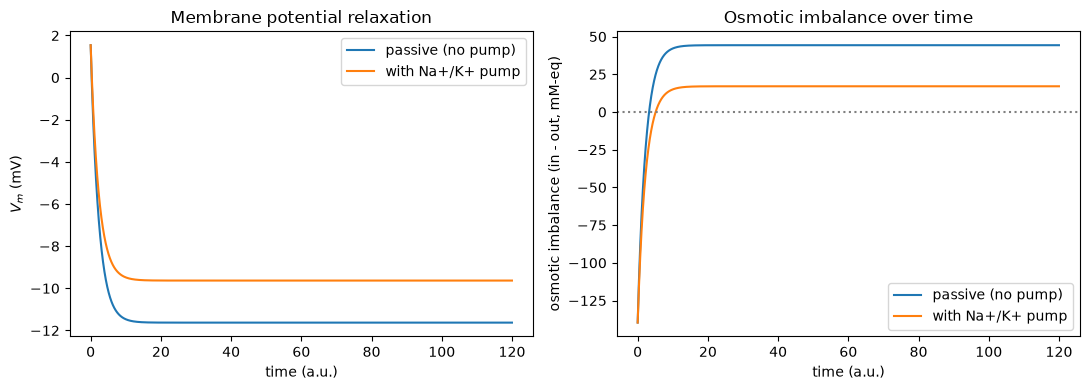

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4), sharey=False)

axes[0].plot(passive["t"], passive["Vm"], label="passive (no pump)")
axes[0].plot(pumped["t"], pumped["Vm"], label="with Na+/K+ pump")
axes[0].set_xlabel("time (a.u.)"); axes[0].set_ylabel("$V_m$ (mV)")
axes[0].set_title("Membrane potential relaxation")
axes[0].legend()

A_INSIDE = 40.0
osm_passive = passive["K_in"] + passive["Cl_in"] + A_INSIDE - (passive["K_out"] + passive["Cl_out"])
osm_pumped  = pumped["K_in"]  + pumped["Cl_in"]  + A_INSIDE - (pumped["K_out"]  + pumped["Cl_out"])
axes[1].plot(passive["t"], osm_passive, label="passive (no pump)")
axes[1].plot(pumped["t"], osm_pumped, label="with Na+/K+ pump")
axes[1].axhline(0, color="gray", ls=":")
axes[1].set_xlabel("time (a.u.)"); axes[1].set_ylabel("osmotic imbalance (in - out, mM-eq)")
axes[1].set_title("Osmotic imbalance over time")
axes[1].legend()

plt.tight_layout()
plt.show()



Note the passive-only run's membrane potential and osmotic imbalance both drift toward the
(non-zero, unstable) Donnan values and keep growing the osmotic gap — that's the swelling drive.
The pumped run's $V_m$ settles near the earlier GHK resting estimate and its osmotic imbalance
stays bounded instead of growing — a genuine steady state, not an equilibrium.

## 7. A physics-engine particle simulation: membrane + gated channels + a pump

The ODE view above is useful for getting the numbers right, but it treats ions as bulk
concentrations, not as actual particles bumping into each other and a membrane. Here we build
a genuine 2D rigid-body physics simulation with [pymunk](http://www.pymunk.org/) (Python bindings
for the Chipmunk2D engine):

- **Ions are physical circles** carrying a charge (+1 for K+/Na+, -1 for Cl-), colliding
  elastically with each other and with the membrane, plus a **softened Coulomb force**
  (attraction between opposite charges, repulsion between like charges) computed every step —
  real electrostatics, not a scripted animation.
- **The membrane** is a wall built from `pymunk.Segment` shapes, with three **gates** — gaps
  in the wall that are selectively permeable using pymunk's collision-filtering system (a gate
  lets its own ion species pass straight through, but still blocks every other species like a
  solid wall). Gate *width* stands in for relative permeability here: the K+ gate is wide
  (high $P_K$), the Cl- gate is medium, and the Na+ gate is deliberately narrow (low $P_{Na}$,
  so Na+ only gets through by chance alignment).
- **The trapped anion A-** is modeled as static (immobile) charged circles fixed inside — too
  big to ever reach a gate, but still exerting a real electrostatic pull on the mobile ions,
  same role as in Parts 3-6.
- **The pump** is scripted, not physics-derived (real active transport spends ATP to do
  something electrodiffusion alone would never do): periodically, it looks for a Na+ near the
  membrane on the inside and a K+ near the membrane on the outside, and forcibly teleports each
  one to the opposite side — a simplified stand-in for the Na+/K+-ATPase actively exporting Na+
  and importing K+ against their gradients.


In [10]:
import pymunk

WIDTH, HEIGHT = 800, 400
MEMBRANE_X = WIDTH / 2

CAT_K, CAT_NA, CAT_CL, CAT_A, CAT_WALL = 1, 2, 4, 8, 16
ALL_CATS = CAT_K | CAT_NA | CAT_CL | CAT_A | CAT_WALL

space = pymunk.Space()
space.gravity = (0, 0)
space.damping = 0.85  # viscous drag -- ions in solution are heavily overdamped, not ballistic

def add_wall(a, b, allow_through_cat=0, radius=2.0):
    """A static wall segment. `allow_through_cat` is excluded from its collision mask,
    so shapes of that category pass straight through -- this is how a 'gate' is built."""
    body = pymunk.Body(body_type=pymunk.Body.STATIC)
    shape = pymunk.Segment(body, a, b, radius)
    shape.elasticity = 0.9
    shape.friction = 0.0
    shape.filter = pymunk.ShapeFilter(categories=CAT_WALL, mask=ALL_CATS & ~allow_through_cat)
    space.add(body, shape)
    return shape

# outer box
add_wall((0, 0), (WIDTH, 0)); add_wall((0, HEIGHT), (WIDTH, HEIGHT))
add_wall((0, 0), (0, HEIGHT)); add_wall((WIDTH, 0), (WIDTH, HEIGHT))

# membrane, built as solid segments with gaps for the 3 selective gates
GATES = {
    "K":  dict(y=(60, 150),  cat=CAT_K),    # wide   -> high P_K
    "Cl": dict(y=(250, 320), cat=CAT_CL),   # medium -> moderate P_Cl
    "Na": dict(y=(195, 205), cat=CAT_NA),   # narrow -> low P_Na
}
breakpoints = sorted([0, HEIGHT] + [y for g in GATES.values() for y in g["y"]])
for y0, y1 in zip(breakpoints[:-1], breakpoints[1:]):
    mid = (y0 + y1) / 2
    allow = next((g["cat"] for g in GATES.values() if g["y"][0] <= mid <= g["y"][1]), 0)
    add_wall((MEMBRANE_X, y0), (MEMBRANE_X, y1), allow_through_cat=allow)

SPECIES = {
    "K":  dict(cat=CAT_K,  q=+1.0, radius=6, color="#4C72B0"),
    "Na": dict(cat=CAT_NA, q=+1.0, radius=6, color="#DD8452"),
    "Cl": dict(cat=CAT_CL, q=-1.0, radius=6, color="#55A868"),
}

mobile = []

def add_ion(species, x, y):
    info = SPECIES[species]
    moment = pymunk.moment_for_circle(1.0, 0, info["radius"])
    body = pymunk.Body(1.0, moment)
    body.position = (x, y)
    shape = pymunk.Circle(body, info["radius"])
    shape.elasticity = 0.9
    shape.friction = 0.0
    shape.filter = pymunk.ShapeFilter(categories=info["cat"], mask=ALL_CATS)
    space.add(body, shape)
    mobile.append(dict(body=body, species=species, q=info["q"]))

rng = np.random.default_rng(0)

def rand_pos(x_lo, x_hi):
    return rng.uniform(x_lo, x_hi), rng.uniform(20, HEIGHT - 20)

# initial ion placement -- loosely mirrors the physiological direction (more K+ in, more Na+/Cl- out)
init_counts = {
    "K":  dict(inside=10, outside=6),
    "Na": dict(inside=4,  outside=14),
    "Cl": dict(inside=6,  outside=14),
}
for species, counts in init_counts.items():
    for _ in range(counts["inside"]):
        add_ion(species, *rand_pos(20, MEMBRANE_X - 20))
    for _ in range(counts["outside"]):
        add_ion(species, *rand_pos(MEMBRANE_X + 20, WIDTH - 20))

# trapped impermeant A-: static, fixed inside, contributes charge but never moves or crosses
A_POSITIONS = [rand_pos(20, MEMBRANE_X - 20) for _ in range(8)]
A_Q = -1.0

print(f"{len(mobile)} mobile ions + {len(A_POSITIONS)} fixed A- anions")


54 mobile ions + 8 fixed A- anions


In [11]:
def coulomb_forces(k=6000.0, softening=100.0, max_force=4000.0):
    """Pairwise softened Coulomb force on every mobile ion, from every other mobile ion
    plus the fixed A- charges. Softened + capped so close encounters don't blow up the
    integrator."""
    n = len(mobile)
    pos = np.array([m["body"].position for m in mobile])
    q = np.array([m["q"] for m in mobile])
    a_pos = np.array(A_POSITIONS)
    a_q = np.full(len(A_POSITIONS), A_Q)

    forces = np.zeros((n, 2))
    for i in range(n):
        d_m = pos[i] - pos
        r2_m = (d_m ** 2).sum(axis=1) + softening
        mag_m = k * q[i] * q / (r2_m ** 1.5)
        mag_m[i] = 0.0
        f = (d_m.T * mag_m).T.sum(axis=0)

        d_a = pos[i] - a_pos
        r2_a = (d_a ** 2).sum(axis=1) + softening
        mag_a = k * q[i] * a_q / (r2_a ** 1.5)
        f = f + (d_a.T * mag_a).T.sum(axis=0)

        forces[i] = f

    norms = np.linalg.norm(forces, axis=1, keepdims=True)
    scale = np.minimum(1.0, max_force / np.maximum(norms, 1e-9))
    return forces * scale

pump_events = []

def try_pump(step, y_zone=(160, 240)):
    """Grab one Na+ near the membrane inside, and one K+ near the membrane outside,
    and forcibly swap their sides -- a scripted stand-in for the Na+/K+-ATPase."""
    na_inside = [m for m in mobile if m["species"] == "Na" and m["body"].position.x < MEMBRANE_X
                 and y_zone[0] < m["body"].position.y < y_zone[1]]
    k_outside = [m for m in mobile if m["species"] == "K" and m["body"].position.x > MEMBRANE_X
                 and y_zone[0] < m["body"].position.y < y_zone[1]]
    if na_inside and k_outside:
        na = min(na_inside, key=lambda m: abs(m["body"].position.x - MEMBRANE_X))
        k = min(k_outside, key=lambda m: abs(m["body"].position.x - MEMBRANE_X))
        na["body"].position = (MEMBRANE_X + 25, na["body"].position.y)
        na["body"].velocity = (30, 0)
        k["body"].position = (MEMBRANE_X - 25, k["body"].position.y)
        k["body"].velocity = (-30, 0)
        pump_events.append(step)

dt = 1 / 60
steps = 2400
record_every = 16
frames = []  # each frame: {species: [(x,y), ...]}

for step in range(steps):
    forces = coulomb_forces()
    for m, f in zip(mobile, forces):
        m["body"].apply_force_at_world_point((f[0], f[1]), m["body"].position)
    for m in mobile:  # thermal jitter -- keeps the "gas" from just freezing under damping
        m["body"].apply_impulse_at_world_point((rng.normal(0, 4), rng.normal(0, 4)), m["body"].position)

    space.step(dt)
    if step % 8 == 0:
        try_pump(step)

    if step % record_every == 0:
        snap = {s: [] for s in SPECIES}
        for m in mobile:
            snap[m["species"]].append(tuple(m["body"].position))
        frames.append(snap)

pump_frame_idx = sorted({e // record_every for e in pump_events})
counts = {}
for m in mobile:
    side = "in" if m["body"].position.x < MEMBRANE_X else "out"
    counts[(m["species"], side)] = counts.get((m["species"], side), 0) + 1

print("Pump fired", len(pump_events), "times over", steps, "steps")
print("Final counts (species, side) -> n:", counts)


Pump fired 4 times over 2400 steps
Final counts (species, side) -> n: {('K', 'in'): 11, ('K', 'out'): 5, ('Na', 'out'): 18, ('Cl', 'in'): 8, ('Cl', 'out'): 12}



Notice the pump fires less and less often as the run goes on: it needs a Na+ near the membrane
*inside* and a K+ near the membrane *outside* at the same time, and both of those become scarcer
as the pump (plus the narrow Na+ gate) does its job — a nice emergent "substrate-limited" throttling
that wasn't scripted directly, it just falls out of the geometry.


In [12]:
plt.rcParams['animation.embed_limit'] = 60  # MB, this animation runs a bit larger than the default 20MB

fig, ax = plt.subplots(figsize=(7, 3.7), dpi=90)
ax.set_xlim(0, WIDTH); ax.set_ylim(0, HEIGHT)
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])

ax.axvspan(MEMBRANE_X - 3, MEMBRANE_X + 3, color="0.85", zorder=0)
for name, g in GATES.items():
    ax.plot([MEMBRANE_X, MEMBRANE_X], g["y"], color="white", lw=6, zorder=1, solid_capstyle="butt")
    ax.text(MEMBRANE_X + 10, sum(g["y"]) / 2, f"{name} gate", fontsize=8, va="center")

for (x, y) in A_POSITIONS:
    ax.add_patch(plt.Circle((x, y), 14, color="0.4", alpha=0.6, zorder=1))
ax.text(20, HEIGHT - 15, "gray circles = trapped A- (immobile)", fontsize=8, color="0.3")

scatters = {s: ax.scatter([], [], s=36, color=info["color"], label=s, zorder=3)
            for s, info in SPECIES.items()}
pump_marker = ax.scatter([], [], s=260, facecolors="none", edgecolors="crimson", linewidths=2, zorder=4)
title = ax.set_title("")
ax.legend(loc="upper right", fontsize=8)

def update(i):
    for s, sc in scatters.items():
        pts = frames[i][s]
        sc.set_offsets(pts if pts else np.empty((0, 2)))
    if i in pump_frame_idx:
        pump_marker.set_offsets([[MEMBRANE_X, 200]])
    else:
        pump_marker.set_offsets(np.empty((0, 2)))
    title.set_text(f"t = {i*record_every*dt:5.2f}  |  pump events so far: {sum(1 for f in pump_frame_idx if f <= i)}")
    return list(scatters.values()) + [pump_marker, title]

anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=30, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())



### Reading the simulation
- Blue (K+) drifts from the outside toward the inside over the run — pulled in by the fixed
  negative A- charges and helped along by the pump.
- Orange (Na+) mostly ends up outside — its gate is narrow (low $P_{Na}$) so passive crossings are
  rare, and the pump actively drags any Na+ that does wander inside back out.
- Green (Cl-) redistributes more freely through its medium gate, settling based on the electrostatic
  balance with the other charges.
- The red ring flashes at the membrane each time the pump fires (a coincident Na+ inside / K+
  outside near the middle gate zone).

This is a qualitative companion to the quantitative ODE/analytic results from Parts 3-6, not a
literal match to those numbers — real ion counts here are tiny (tens, not moles), and the
electrostatics are a simplified 2D softened-Coulomb approximation, not full 3D Debye screening.
What it does capture directly, as actual emergent particle behavior rather than a scripted curve,
is: selective permeability (gate width), a trapped charge pulling in a counter-ion, and an active
pump running against the passive gradient.

### Where to take this next
- Make gate width or pump rate a live-adjustable parameter (e.g. via `ipywidgets`) and re-render.
- Add a live-updating $V_m$-style readout (e.g. net charge difference across the membrane) as a
  second panel next to the particle view.
- Swap the scripted pump for something that only fires when a Na+/K+ pair is *bound* at the gate
  (a docking-radius check) rather than anywhere in a wide capture zone, for a more mechanistic feel.
- Extend to 3 gates + an explicit voltage-gated Na+ channel that opens when local charge density
  crosses a threshold, to get a crude spatial action-potential propagation.
